<a href="https://colab.research.google.com/github/martinacssll/chemoinformatics/blob/main/MOOC_assignments/scoring_generated_molecules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scoring Generated Molecules - SAScore, QED, steroid penalty - global score

This activity directly extends the exercise from the previous unit. Use the same Glucocorticoid receptor generated sets, the same DrugEx_GT_epsilon_0.6 and GB_GA_mut_r_0.5 sets, and the same reference chemistry context from CHEMBL2034. Instead of focusing only on visualization, you will now build a small scoring workflow that helps rank molecules from those generated sets and evaluate them against the reference chemistry.

## Learning goals

- Compute synthetic accessibility scores with SAScore.
- Compute drug-likeness scores with QED.
- Design a good project-specific custom score (also using the reference chemistry context).
- Rank the generated compounds and compare the success of the two generators in terms of your scoring criteria.
- Compare the top-ranked molecules from each generator to the reference chemistry and visualize their locations in chemical space.

## Activity overview

Start from the prepared molecular datasets you used in the chemspace activity. The main objective here is to calculate the appropriate **scores** for each molecule and suggest a suitable **ranking strategy**, which would maximize the chance of finding <u>non-steroidal</u>, <u>synthetically accessible</u>, and <u>drug-like</u> compounds in the generated sets. You will also *compare the two generators* in terms of their ability to produce such molecules in terms of their outputs (the DrugEx_GT_epsilon_0.6 and GB_GA_mut_r_0.5 sets).

## Suggested scoring components

Below are three scoring components that you can use to rank the generated molecules, but they are mere suggestions. You are free to design your own scoring strategy, but you must justify your choices.

**1 <u>SAScore</u> for synthetic accessibility**

Use the RDKit-compatible SAScore implementation that is commonly distributed with RDKit contribution scripts.
Remember that lower values are generally better.

**2 <u>QED</u> for drug-likeness**

Use `rdkit.Chem.QED.qed(mol)` to compute a score between 0 and 1.
Higher values are generally better.

**3 A specialized <u>non-steroidal prioritization score</u>**

Build your own score that favors non-steroidal compounds from the generated sets.
The purpose is to prioritize alternatives to steroid-like chemistry while still keeping compounds reasonably accessible and drug-like.

> You are free to define the detection rule, but you must document it. Reasonable options include:

> - using a *SMARTS pattern* for a fused tetracyclic steroid-like core
> - using *ring system heuristics* that detect the characteristic fused four-ring framework
> - using a curated list of steroid reference scaffolds and a *similarity-based penalty*

> The most important requirement is that your score should clearly separate compounds you would consider steroid-like from compounds you would consider non-steroidal. You can use a chemical space visualization to inspect the results of your steroid detection rule and make sure it aligns with your expectations.

**4 <u>QSAR model</u>**

Use the CHEMBL2034 data set to train a simple QSAR model for glucocorticoid receptor activity. Choose a suitable endpoint using the activity charts and train the model using whatever machine learning approach you prefer.

### Example custom score design

One possible form is:

```
score_custom = w1 * QED + w2 * synth_term - w3 * steroid_penalty + w4 * QSAR_predicted_activity
```

where:

- `QED` is scaled between 0 and 1 so that higher values are better
- `synth_term` is a transformed version of SAScore that is also scaled between 0 and 1 (e.g., with a suitable sigmoid function) so that higher values are better
- `steroid_penalty` is 1 for steroid-like molecules and 0 for non-steroidal molecules, or a continuous similarity-based penalty also scaled between 0 and 1
- `QSAR_predicted_activity` is a predicted probability of activity from your QSAR model, scaled between 0 and 1

You may choose the weights in your score manually or use a simple optimization strategy to find weights that maximize the number of non-steroidal, synthetically accessible, and drug-like compounds in the top-ranked molecules from the reference chemistry context (CHEMBL2034).

## Suggested workflow

1. Reuse the prepared generated datasets from the chemspace exercise.

4. Compute QED for each molecule.

5. Compute SAScore for each molecule.

6. Define and compute your steroid or non-steroidal penalty term.

7. Train a QSAR model for glucocorticoid receptor activity and compute predicted activity scores for each molecule.

8. Normalize or transform the score components so they are numerically comparable as outlined in the weighted sum score example above.

9. Construct your custom scoring function (optimize weights if desired).

10. Rank the molecules within each generator output set.

11. Compare the top-ranked molecules from the DrugEx_GT_epsilon_0.6 and GB_GA_mut_r_0.5 sets in terms of their scores and contrast them with the reference chemistry context (CHEMBL2034).

12. Map the top-ranked and bottom-ranked compounds back onto your chemspace visualizations from the previous activity.

## 0. Setup and Datasets



In [2]:
# Download RDKit and sasscorer.py
!pip -q install RDKit
!wget -q -O sascorer.py https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py
!wget -q -O fpscores.pkl.gz https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 28.2 MB/s eta 0:00:00


In [64]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors, rdMolDescriptors, QED
from rdkit.Chem.Draw import MolsToGridImage

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import sys
import os

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The following cell uploads the file that contains the *de novo* curated dataset as generated in the *QSAR_model.ipynb* notebook. It contains the curated dataset SMILES, fingerprints and descriptors, and predicted pIC50 with its associated confidence flags.

In [5]:
# Read the file
df_denovo = pd.read_csv('drive/MyDrive/data/denovo_predictions_random.csv')
print(f"Number of molecules: {len(df_denovo)}")
print(f"Columns: {list(df_denovo.columns)}")

# Generate the Mol files from the SMILES
def smiles_to_mol(smiles):
    if pd.isna(smiles):
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        print(f"Failed to parse SMILES: {smiles}")
        return None

# Calculate fingerprints
def morgan_fingerprints(mol, radius=2, nBits=2048):
    if mol is None:
        return None
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits)
    fp = mfpgen.GetFingerprintAsNumPy(mol)  # as numpy array for sklearn
    return fp

df_denovo['mol'] = df_denovo['canonical_smiles'].apply(smiles_to_mol)
df_denovo['fp'] = df_denovo['mol'].apply(morgan_fingerprints)
df_denovo

Number of molecules: 99876
Columns: ['mol', 'canonical_smiles', 'source', 'fp', 'MW', 'LogP', 'TPSA', 'HBD', 'RotBonds', 'AromaticRings', 'FractionCSP3', 'pIC50_pred', 'leverage', 'tanimoto_nn_sim', 'out_of_domain_leverage', 'out_of_domain_tanimoto', 'low_confidence']


,mol,canonical_smiles,source,fp,MW,LogP,TPSA,HBD,RotBonds,AromaticRings,FractionCSP3,pIC50_pred,leverage,tanimoto_nn_sim,out_of_domain_leverage,out_of_domain_tanimoto,low_confidence
0,<rdkit.Chem.rdchem.Mol object at 0x7ea3f3dc0270>,Cc1cccc(N(CC(C)C)C(=O)COC(=O)c2ccc3c(c2)COC(C2...,DrugEx_GT,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",493.644,6.00734,65.07,0.0,7.0,2.0,0.533333,7.276394,0.007246,0.237624,False,True,True
1,<rdkit.Chem.rdchem.Mol object at 0x7ea3f3dc0350>,Cc1cc(-c2ccc(C(C)COCc3ccccc3)c3cc[nH]c23)c(C=N...,DrugEx_GT,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",512.650,6.13132,98.07,4.0,7.0,4.0,0.343750,7.772216,0.009728,0.310345,False,False,False
2,<rdkit.Chem.rdchem.Mol object at 0x7ea3f3dc03c0>,CC(=CC=C1C=CC(C)(c2ccccn2)CO1)C1C(=N)N1C(C1CC1...,DrugEx_GT,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",496.602,4.73287,92.07,2.0,10.0,1.0,0.535714,7.750180,0.008119,0.198113,False,True,True
3,<rdkit.Chem.rdchem.Mol object at 0x7ea3f3dc0430>,CC#CC1(O)CCC2C3CCC4=CC(=O)CCC4=C3C(c3ccc(CNCCO...,DrugEx_GT,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",475.629,4.00640,78.79,3.0,5.0,1.0,0.566667,7.624100,0.005212,0.550000,False,False,False
4,<rdkit.Chem.rdchem.Mol object at 0x7ea3f3dc04a0>,CC(C)CC(O)(Cc1cc2cc(-c3ccccc3S(N)(=O)=O)ncc2[n...,DrugEx_GT,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",441.475,3.75930,109.07,3.0,6.0,3.0,0.350000,7.584062,0.004311,0.585714,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99871,<rdkit.Chem.rdchem.Mol object at 0x7ea3f39a3370>,Cc1cc(C(F)(F)F)cc(C)c1S(=O)(=O)OOC(O)Cc1c[nH]c...,GB_GA,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",429.416,4.00154,88.62,2.0,6.0,3.0,0.263158,7.215282,0.001622,0.523810,False,False,False
99872,<rdkit.Chem.rdchem.Mol object at 0x7ea3f39a33e0>,C=CCOc1c(C)cc([C@H]2C[C@@]3(C)[C@@H](CC[C@@]3(...,GB_GA,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",503.082,7.32132,43.37,0.0,4.0,1.0,0.500000,7.295174,0.011235,0.494382,False,False,False
99873,<rdkit.Chem.rdchem.Mol object at 0x7ea3f39a3450>,C[C@@H](CNc1cccc2c1cnn2-c1ccc(F)cc1)NS(=O)(=O)...,GB_GA,"[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",639.197,5.96660,124.93,4.0,12.0,5.0,0.375000,7.561760,0.012785,0.473684,False,False,False
99874,<rdkit.Chem.rdchem.Mol object at 0x7ea3f39a34c0>,O=C(CF)C(=O)CSc1ccccn1,GB_GA,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",213.233,1.28140,47.03,0.0,5.0,1.0,0.222222,6.288636,0.020290,0.305556,False,False,False


In [6]:
MOL_COL = "mol"

## 1. QED (Quantitative Estimate of Drug-Likeness)

- Score that combines physicochemical properties (MW, LogP, HBond, polarity, etc.) to assess drug-likeness of a molecule

- **Values**: 0 (bad) - 1 (excellent)

In [7]:
# Calculate QED
df_denovo["QED"] = df_denovo[MOL_COL].apply(QED.qed)

In [8]:
df_denovo["QED"].describe()

,QED
count,99876.000000
mean,0.477141
std,0.188299
min,0.007478
25%,0.329431
50%,0.467848
75%,0.616747
max,0.948136


## 2. SaScore (Synthetic Accessibility Score)

- Score that evaluates synthetic feasibility of a molecule

- **Values**: 1 (easy) - 10 (hard)

In [9]:
# Calculate SaScore
SASCORER_PATH = "."
if SASCORER_PATH not in sys.path:
    sys.path.append(SASCORER_PATH)

try:
    import sascorer
    df_denovo["SAS"] = df_denovo[MOL_COL].apply(sascorer.calculateScore)
except ImportError:
    print("Warning: sascorer not found. Download sascorer.py and fpscores.pkl.gz")
    print("from https://github.com/rdkit/rdkit/tree/master/Contrib/SA_Score")
    print("and set SASCORER_PATH to the right path")

In [10]:
df_denovo["SAS"].describe()

,SAS
count,99876.000000
mean,3.939099
std,0.926068
min,1.028426
25%,3.330199
50%,3.868340
75%,4.533175
max,8.158921


## 3. Non-steroidal prioritization score

- Score that penalizes steroid-like structures

- *Steroidal structures detection*: via SMARTS steroid scaffold identification

- **Values**: binary, 0 (steroidal), 1 (non-steroidal)

Note - A continuous similarity-based score would be better.

In [11]:
# SMARTS for the steroid scaffold
STEROID_SMARTS = "[#6]1[#6][#6][#6]2[#6]1[#6][#6][#6]1[#6]2[#6][#6][#6]2[#6]1[#6][#6][#6][#6]2"
steroid_pattern = Chem.MolFromSmarts(STEROID_SMARTS)

def has_steroid_scaffold(mol):
    if mol is None:
        return False
    return mol.HasSubstructMatch(steroid_pattern)

# Detect steroid scaffold
df_denovo["has_steroid_scaffold"] = df_denovo[MOL_COL].apply(has_steroid_scaffold)

# Compute non-steroidal prioritization score
df_denovo["steroid_penalty_score"] = (~df_denovo["has_steroid_scaffold"]).astype(float)

print(f"\nMolecules with steroidal scaffold detected: {df_denovo['has_steroid_scaffold'].sum()} "
      f"({100 * df_denovo['has_steroid_scaffold'].mean():.1f}%)")


Molecules with steroidal scaffold detected: 1005 (1.0%)


Explained variance: PC1=4.65%, PC2=3.20%


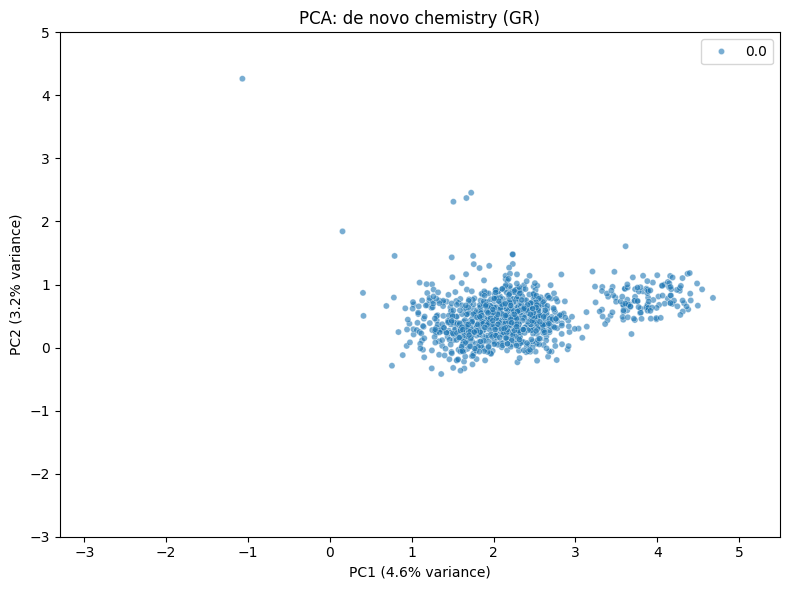

In [12]:
# Check were steroidal structures lie in PCA - via fingerprint
# PCA
# X values: DataFrame of the features in columns turned to a numpy array
X = np.stack(df_denovo['fp'].values)  # shape: (n_samples, 2048)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
# pca_result: numpy array of shape (n_samples, n_components), transformed coordinates of each sample in the PC space

df_denovo['PC1_fp'] = pca_result[:, 0]
df_denovo['PC2_fp'] = pca_result[:, 1]

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

# Plot data in PC space
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_denovo[df_denovo['steroid_penalty_score'] == 0], x='PC1_fp', y='PC2_fp', hue='steroid_penalty_score', alpha=0.6, s=20)

plt.xlim(-3.3,5.5)
plt.ylim(-3, 5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA: de novo chemistry (GR)')
plt.legend()
plt.tight_layout()

Explained variance: PC1=41.53%, PC2=25.53%


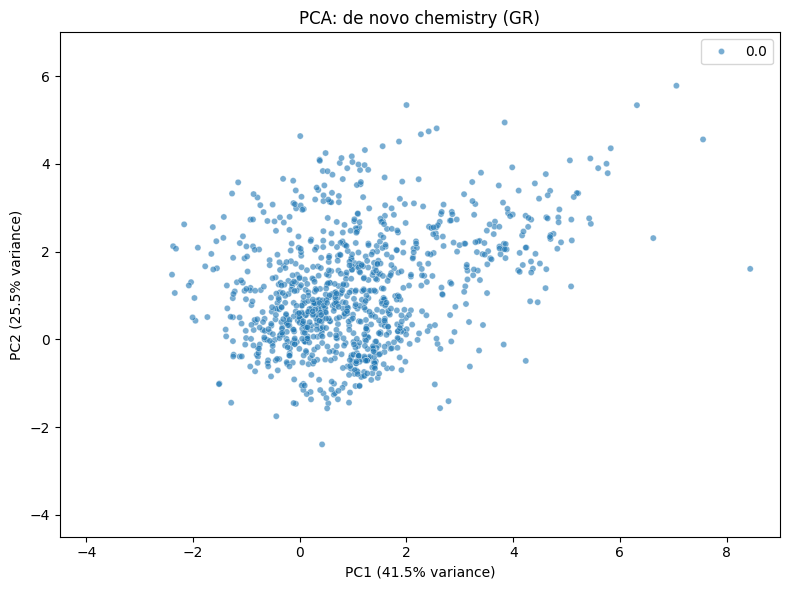

In [13]:
# Check were steroidal structures lie in PCA - via descriptors
# PCA
# X values: DataFrame of the features in columns turned to a numpy array
descriptor_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'RotBonds', 'AromaticRings', 'FractionCSP3']

X = df_denovo[descriptor_cols].values # shape: (n_samples, n_descriptors)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
# pca_result: numpy array of shape (n_samples, n_components), transformed coordinates of each sample in the PC space

df_denovo['PC1_desc'] = pca_result[:, 0]
df_denovo['PC2_desc'] = pca_result[:, 1]

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

# Plot data in PC space
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_denovo[df_denovo['steroid_penalty_score'] == 0], x='PC1_desc', y='PC2_desc', hue='steroid_penalty_score', alpha=0.6, s=20)

plt.xlim(-4.5,9)
plt.ylim(-4.5, 7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA: de novo chemistry (GR)')
plt.legend()
plt.tight_layout()

## 4. Composite score

- Normalization of the QSAR activity, (QED), SaScore and non-steroidal prioritization score
- Compute the composite score with fixed weights
- Rank compounds from each generator
- Visualize each score
- Map top-ranked and bottom-ranked compounds into the previous chemical space visualizations; compare with reference chemistry

In [14]:
# Normalization
# 1. QSAR activity: min-max normalization
df_denovo["qsar_norm"] = (
    (df_denovo["pIC50_pred"] - df_denovo["pIC50_pred"].min()) /
    (df_denovo["pIC50_pred"].max() - df_denovo["pIC50_pred"].min())
)

# 2. QED: already 0-1 by construction
df_denovo["qed_norm"] = df_denovo["QED"]

# 3. SAS: 1 (easy) - 10 (hard)
# Normalization via sigmoid function (more gradual penalization around a central threshold)
# sigmoid(x) = 1 / (1 + exp(k * (x - x0)))
# - x0: central threshold, es. 5
# - k: slope of the transition (higher k = more abrupt transition)
SAS_MIDPOINT = 5.0   # midpoint (rapid decrease in synthesizability for values > SAS_MIDPOINT)
SAS_STEEPNESS = 1.0  # steepness of transition around midpoint

df_denovo["sas_norm"] = 1 / (1 + np.exp(SAS_STEEPNESS * (df_denovo["SAS"] - SAS_MIDPOINT)))

# Steroid penalty: already 0-1 (1 = non-steroidal - no penalty, 0 = steroidal - penalty)
df_denovo["steroid_penalty_norm"] = df_denovo["steroid_penalty_score"]

In [16]:
# Confidence factor from applicability domain of the QSAR model
# Leverage threshold according to OECD
p = len(descriptor_cols)  # num descriptors
n = 1168                  # num data used to train the QSAR model
h_star = 3 * (p + 1) / n

# Confidence factor: minimum between confidence_tanimoto (0 dissimilar, 1 equal) and confidence_factor (0 high leverage, 1 low leverage)
df_denovo["confidence_tanimoto"] = df_denovo["tanimoto_nn_sim"].clip(0, 1)
df_denovo["confidence_leverage"] = 1 / (1 + df_denovo["leverage"] / h_star)
df_denovo["confidence_factor"] = np.minimum(
    df_denovo["confidence_tanimoto"],
    df_denovo["confidence_leverage"]
)

In [17]:
df_denovo['confidence_factor'].describe()

,confidence_factor
count,99876.000000
mean,0.403165
std,0.166886
min,0.039474
25%,0.265823
50%,0.382716
75%,0.522388
max,0.950168


In [20]:
# Composite score
# - qsar_activity (0.40): main objective
# - qed (0.20): drug-likeness, quality criterion
# - sas (0.20): synthetic feasibility, practical criterion
# - steroid_penalty (0.20): penalty for scaffolds at risk of off-target effects
WEIGHTS = {
    "qsar_activity": 0.40,
    "qed": 0.20,
    "sas": 0.20,
    "steroid_penalty": 0.20,
}

df_denovo["composite_score"] = (
    WEIGHTS["qsar_activity"] * df_denovo["qsar_norm"] +
    WEIGHTS["qed"] * df_denovo["qed_norm"] +
    WEIGHTS["sas"] * df_denovo["sas_norm"] +
    WEIGHTS["steroid_penalty"] * df_denovo["steroid_penalty_norm"]
)

# Apply the QSAR confidence score as a final factor
df_denovo["adjusted_score"] = df_denovo["composite_score"] * df_denovo["confidence_factor"]

In [22]:
print(df_denovo["composite_score"].describe())
print("\n")
print(df_denovo["adjusted_score"].describe())

count    99876.000000
mean         0.601726
std          0.061069
min          0.195395
25%          0.567113
50%          0.607131
75%          0.643274
max          0.843909
Name: composite_score, dtype: float64


count    99876.000000
mean         0.247355
std          0.114723
min          0.013787
25%          0.155569
50%          0.230477
75%          0.325026
max          0.699239
Name: adjusted_score, dtype: float64


In [31]:
# Final ranking
df_ranked = df_denovo.sort_values("adjusted_score", ascending=False)

top_n = 20
df_top = df_denovo.sort_values("adjusted_score", ascending=False).head(top_n)

print(f"\n--- Top {top_n} molecules by adjusted_score ---")
print(df_top[["pIC50_pred", "QED", "SAS", "steroid_penalty_norm",
              "confidence_factor", "composite_score", "adjusted_score"]]
      .round(3).to_string())


--- Top 20 molecules by adjusted_score ---
       pIC50_pred    QED    SAS  steroid_penalty_norm  confidence_factor  composite_score  adjusted_score
45027      10.125  0.384  3.372                   1.0              0.829            0.844           0.699
44347       9.921  0.309  3.238                   1.0              0.855            0.816           0.698
45983       9.367  0.362  3.304                   1.0              0.888            0.781           0.693
94122       8.006  0.901  3.640                   1.0              0.892            0.770           0.687
63927       9.321  0.357  3.239                   1.0              0.883            0.778           0.687
34147       9.046  0.416  3.101                   1.0              0.890            0.771           0.686
89449       9.812  0.293  3.429                   1.0              0.855            0.799           0.683
47155       8.686  0.467  3.855                   1.0              0.932            0.730           0.680
66

Visualize each score contributing to the composite score.

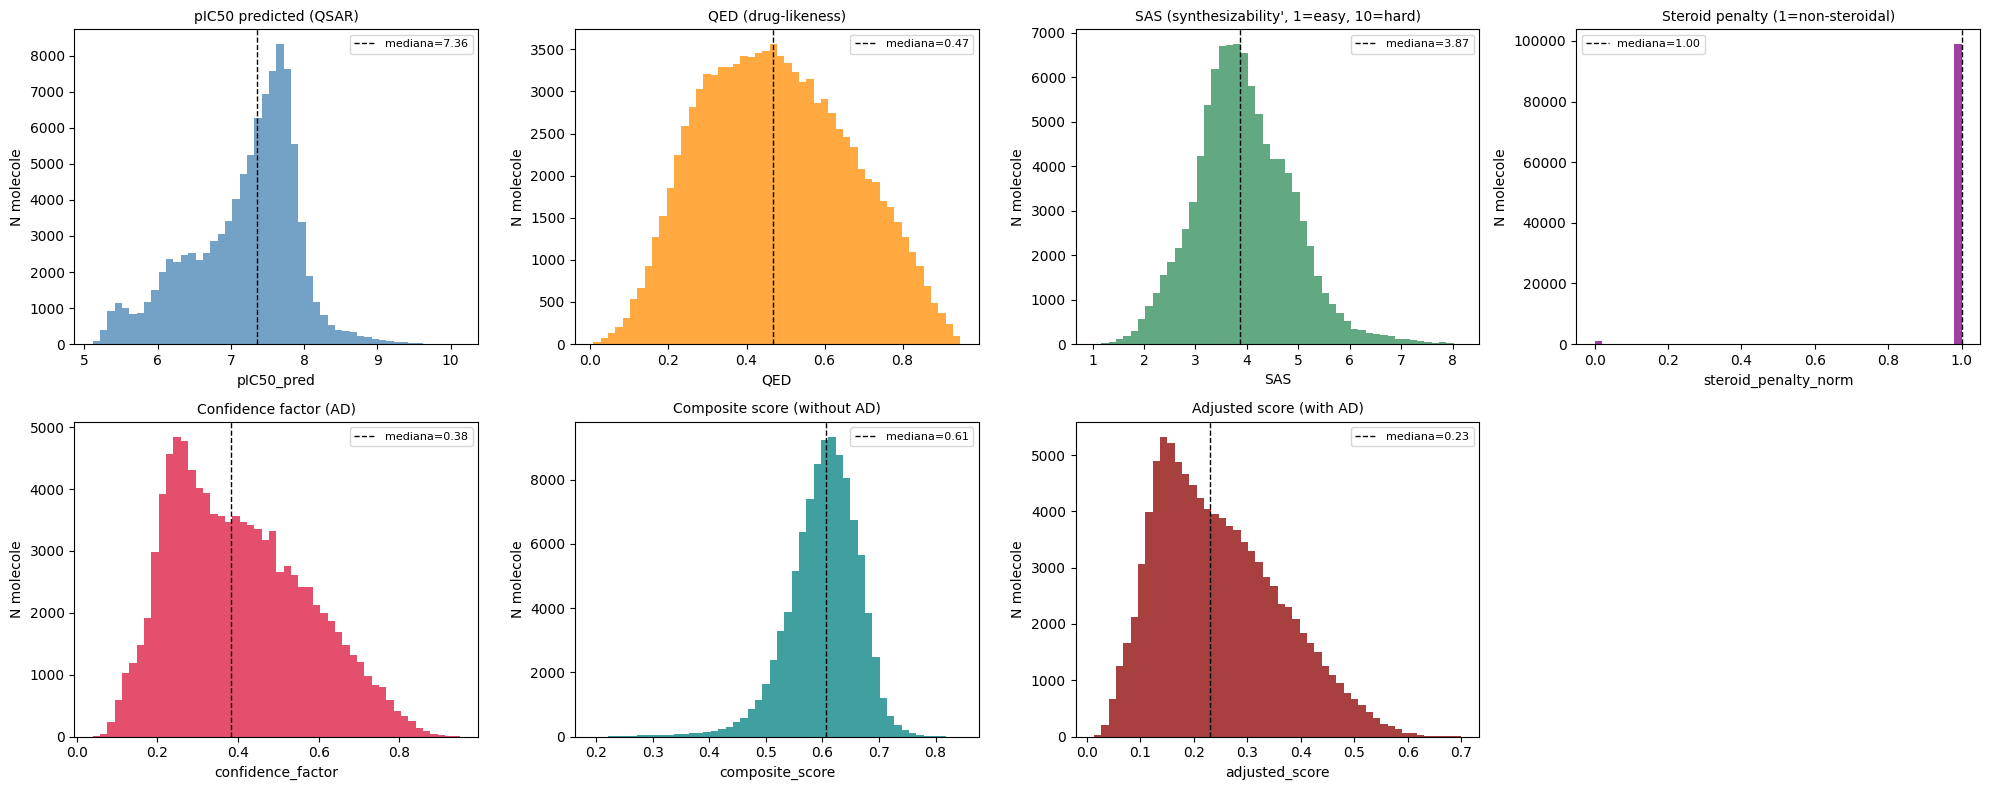

In [29]:
# Histograms
components = [
    ("pIC50_pred", "pIC50 predicted (QSAR)", "steelblue"),
    ("QED", "QED (drug-likeness)", "darkorange"),
    ("SAS", "SAS (synthesizability', 1=easy, 10=hard)", "seagreen"),
    ("steroid_penalty_norm", "Steroid penalty (1=non-steroidal)", "purple"),
    ("confidence_factor", "Confidence factor (AD)", "crimson"),
    ("composite_score", "Composite score (without AD)", "teal"),
    ("adjusted_score", "Adjusted score (with AD)", "darkred"),
]

n_cols = 4
n_rows = int(np.ceil(len(components) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, (col, title, color) in enumerate(components):
    ax = axes[i]
    ax.hist(df_denovo[col].dropna(), bins=50, color=color, alpha=0.75, edgecolor="none")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel("N molecole")
    ax.axvline(df_denovo[col].median(), color="black", linestyle="--", linewidth=1,
               label=f"mediana={df_denovo[col].median():.2f}")
    ax.legend(fontsize=8)

# Hide empty subplots
for j in range(len(components), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("scores_distributions_grid.png", dpi=150, bbox_inches="tight")
plt.show()

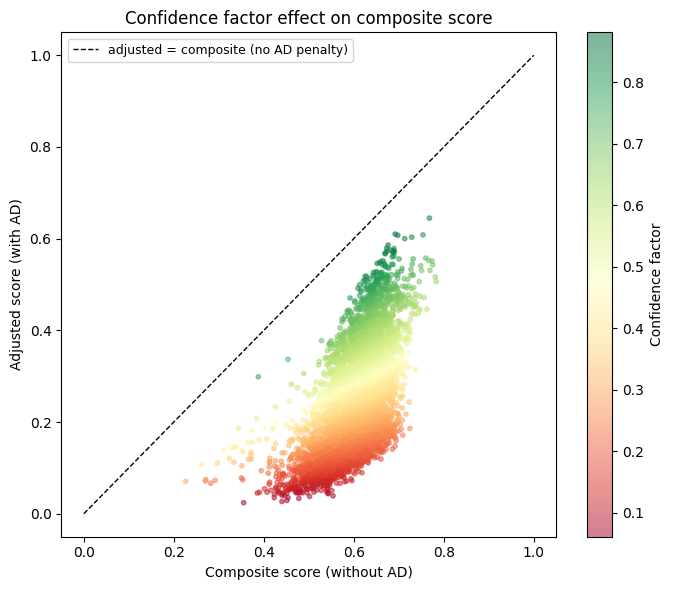

In [35]:
# Scatter
plot_sample = df_denovo.sample(n=min(5000, len(df_denovo)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(plot_sample["composite_score"], plot_sample["adjusted_score"],
                      c=plot_sample["confidence_factor"], cmap="RdYlGn", alpha=0.5, s=10)
lims = [0, 1]
ax.plot(lims, lims, "k--", linewidth=1, label="adjusted = composite (no AD penalty)")
ax.set_xlabel("Composite score (without AD)")
ax.set_ylabel("Adjusted score (with AD)")
ax.set_title("Confidence factor effect on composite score")
ax.legend(fontsize=9)
plt.colorbar(scatter, label="Confidence factor")

plt.tight_layout()
plt.savefig("composite_vs_adjusted_score.png", dpi=150, bbox_inches="tight")
plt.show()

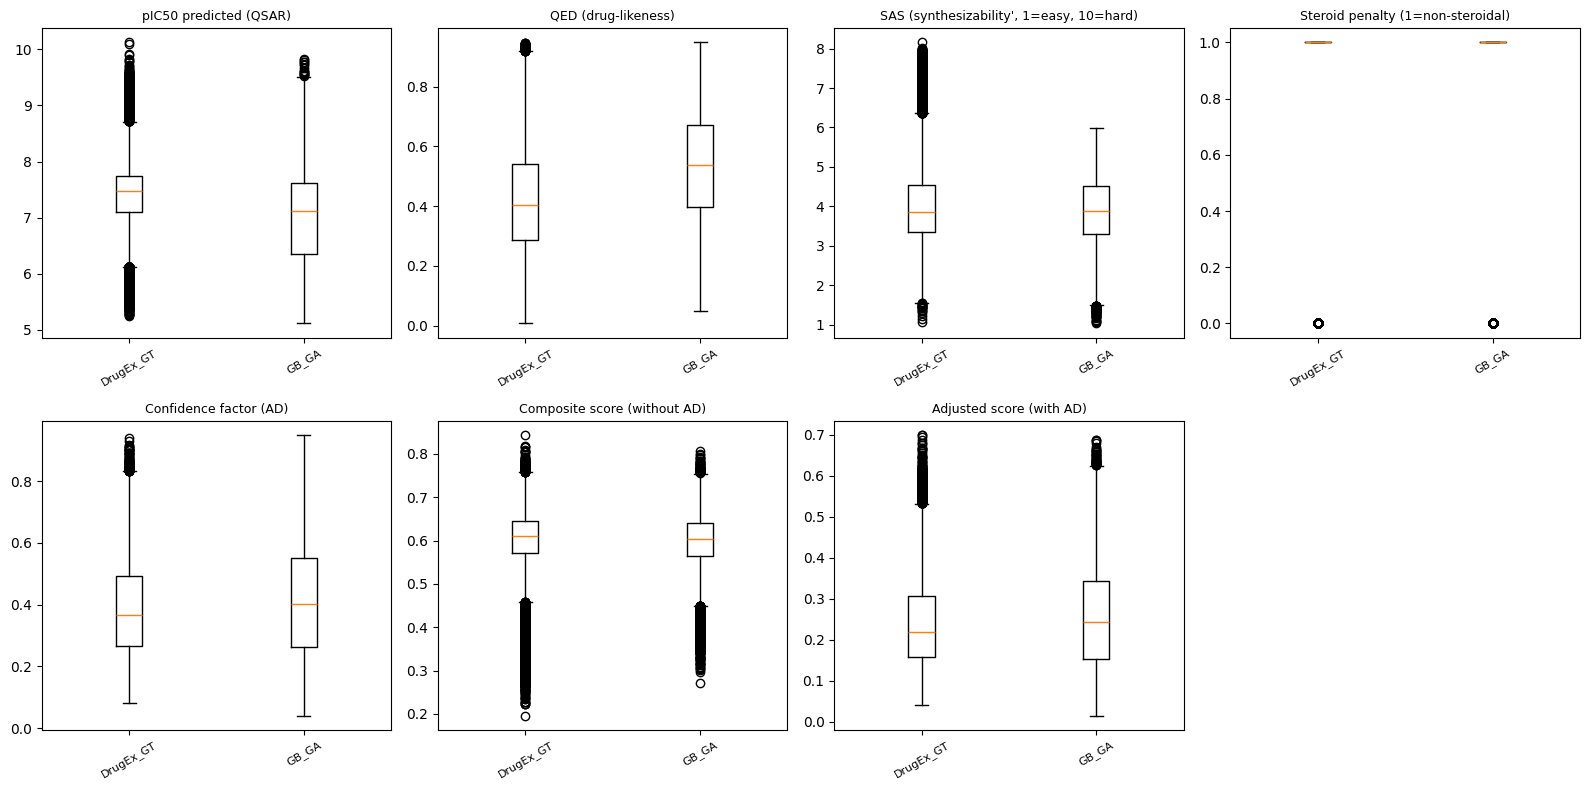

In [45]:
# Box plot to compare the two generators
SOURCE_COL = "source"

n_cols_box = int(np.ceil(len(components) / 2))
fig, axes = plt.subplots(2, n_cols_box, figsize=(4 * n_cols_box, 8))
axes = axes.flatten()

for i, (col, title, _) in enumerate(components):
    ax = axes[i]
    data_by_source = [
        df_denovo.loc[df_denovo[SOURCE_COL] == src, col].dropna()
        for src in df_denovo[SOURCE_COL].unique()
    ]
    ax.boxplot(data_by_source, tick_labels=df_denovo[SOURCE_COL].unique())
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis="x", rotation=30, labelsize=8)

for j in range(len(components), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("scores_by_source_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

- **Activity**: DrugEx shortest and higher activities, both outliers in lower activities (probably less common structures outside of AD)

- **QED**: GB_GA more drug-like compounds

- **SAS**: similar, both have some high values

- **Steroid penalty**: most molecules are not steroidal for both generators (or the detection criterion is too restrictive)

- *Confidence factor (AD)*: more favourable for GB_GA - GB_GA is closer to the training set

- Similar scores without AD, GB_GA slightly higher scores with AD (because it has higher confidence factors)

### PCA, t-SNE - Fingerprints

In [51]:
# Upload reference chemistry dataset
df_reference = pd.read_csv('drive/MyDrive/data/df_refchem_clean.csv')
print(f"Number of molecules: {len(df_reference)}")
print(f"Columns: {list(df_reference.columns)}")

# Generate Mol and calculate fingerprints
df_reference['mol'] = df_reference['canonical_smiles'].apply(smiles_to_mol)
df_reference['fp'] = df_reference['mol'].apply(morgan_fingerprints)

# Calculate descriptors
descriptor_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'RotBonds', 'AromaticRings', 'FractionCSP3']

def calc_descriptors(mol):
    if mol is None:
        return None
    return pd.Series({
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'RotBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
        'FractionCSP3': rdMolDescriptors.CalcFractionCSP3(mol)
    })

df_reference[descriptor_cols] = df_reference['mol'].apply(calc_descriptors)
df_reference

Number of molecules: 1460
Columns: ['mol', 'canonical_smiles', 'pIC50', 'molecule_chembl_id']


,mol,canonical_smiles,pIC50,molecule_chembl_id,fp,MW,LogP,TPSA,HBD,RotBonds,AromaticRings,FractionCSP3
0,<rdkit.Chem.rdchem.Mol object at 0x7ea3eaf6f8b0>,C#CC1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4[C@...,6.826814,CHEMBL2107797,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",312.453,3.8826,37.30,1.0,1.0,0.0,0.761905
1,<rdkit.Chem.rdchem.Mol object at 0x7ea3eb883370>,C#CC1=C(SCC(=O)c2ccccc2)NC(C)=C(C(C)=O)C1c1cccs1,5.730487,CHEMBL5267245,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",393.533,4.7588,46.17,1.0,6.0,2.0,0.181818
2,<rdkit.Chem.rdchem.Mol object at 0x7ea3eb883290>,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4...,6.363512,CHEMBL1162,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",298.426,3.4925,37.30,1.0,0.0,0.0,0.750000
3,<rdkit.Chem.rdchem.Mol object at 0x7ea3eb883220>,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(C...,6.679854,CHEMBL241694,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",312.453,3.8826,37.30,1.0,0.0,0.0,0.761905
4,<rdkit.Chem.rdchem.Mol object at 0x7ea3eb8831b0>,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=Cc5oncc5C[C@]4(...,5.365120,CHEMBL1479,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",337.463,4.2210,46.26,1.0,0.0,1.0,0.681818
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,<rdkit.Chem.rdchem.Mol object at 0x7ea3ef1107b0>,O[C@]1(c2ccccc2)CCCC[C@@]12C=Cc1c(cnn1-c1ccc(F...,5.994819,CHEMBL4446696,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",374.459,5.0289,38.05,1.0,2.0,3.0,0.291667
1456,<rdkit.Chem.rdchem.Mol object at 0x7ea3ef110820>,Oc1ccc(-c2ccc3c(cnn3-c3ccc(F)cc3)c2)cc1,6.199998,CHEMBL1084344,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",304.324,4.5372,38.05,1.0,2.0,4.0,0.000000
1457,<rdkit.Chem.rdchem.Mol object at 0x7ea3ef110890>,Oc1ccc(C2=CCCC[C@]23C=Cc2c(cnn2-c2ccc(F)cc2)C3...,8.000000,CHEMBL4536521,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",372.443,5.5402,38.05,1.0,2.0,3.0,0.208333
1458,<rdkit.Chem.rdchem.Mol object at 0x7ea3ef110900>,Oc1cccc(-c2ccc3c(cnn3-c3ccc(F)cc3)c2)c1,6.099999,CHEMBL1083885,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",304.324,4.5372,38.05,1.0,2.0,4.0,0.000000


In [54]:
# Combine datasets
FP_COL = "fp"

X_denovo_fp = np.vstack(df_denovo[FP_COL].values).astype(np.int8)
X_reference_fp = np.vstack(df_reference[FP_COL].values).astype(np.int8)

X_combined_fp = np.vstack([X_denovo_fp, X_reference_fp])

# Source labels
origin_labels = (["de novo"] * len(df_denovo)) + (["reference"] * len(df_reference))

print(f"De novo molecules: {len(df_denovo)}")
print(f"Reference molecules: {len(df_reference)}")
print(f"Combined total: {X_combined_fp.shape[0]}")

De novo molecules: 99876
Reference molecules: 1460
Combined total: 101336


In [56]:
# Define subsample for efficiency and visualization
MAX_DENOVO_POINTS = 5000

denovo_sample_idx = np.random.RandomState(42).choice(
    len(df_denovo), size=min(MAX_DENOVO_POINTS, len(df_denovo)), replace=False
)

df_denovo_sample = df_denovo.iloc[denovo_sample_idx].reset_index(drop=True)
df_reference_sample = df_reference.reset_index(drop=True)  # keep all reference

X_denovo_fp_sample = X_denovo_fp[denovo_sample_idx]
X_reference_fp_sample = X_reference_fp  # keep all reference

X_combined_sample = np.vstack([X_denovo_fp_sample, X_reference_fp_sample])
origin_sample = (["de novo"] * len(df_denovo_sample)) + (["reference"] * len(df_reference_sample))

print(f"\nSample for PCA/tSNE: {len(df_denovo_sample)} de novo (sampled) + "
      f"{len(df_reference_sample)} reference (all) = {X_combined_sample.shape[0]} total")


Sample for PCA/tSNE: 5000 de novo (sampled) + 1460 reference (all) = 6460 total


In [57]:
# PCA
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_combined_sample)

print(f"\nPCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}")


PCA explained variance: PC1=5.4%, PC2=3.6%


In [59]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_coords = tsne.fit_transform(X_combined_sample.astype(np.float32))

In [60]:
# Create a dataset with coordinates and scores for the de novo dataset
plot_df = pd.DataFrame({
    "PC1": pca_coords[:, 0],
    "PC2": pca_coords[:, 1],
    "tSNE1": tsne_coords[:, 0],
    "tSNE2": tsne_coords[:, 1],
    "origin": origin_sample,
})

# Score (available for de novo only)
score_cols = ["pIC50_pred", "QED", "SAS", "confidence_factor", "adjusted_score"]
for col in score_cols:
    if col in df_denovo_sample.columns:
        values = pd.concat([
            df_denovo_sample[col],
            pd.Series([np.nan] * len(df_reference_sample))  # reference: NaN se non calcolato
        ], ignore_index=True)
        plot_df[col] = values.values

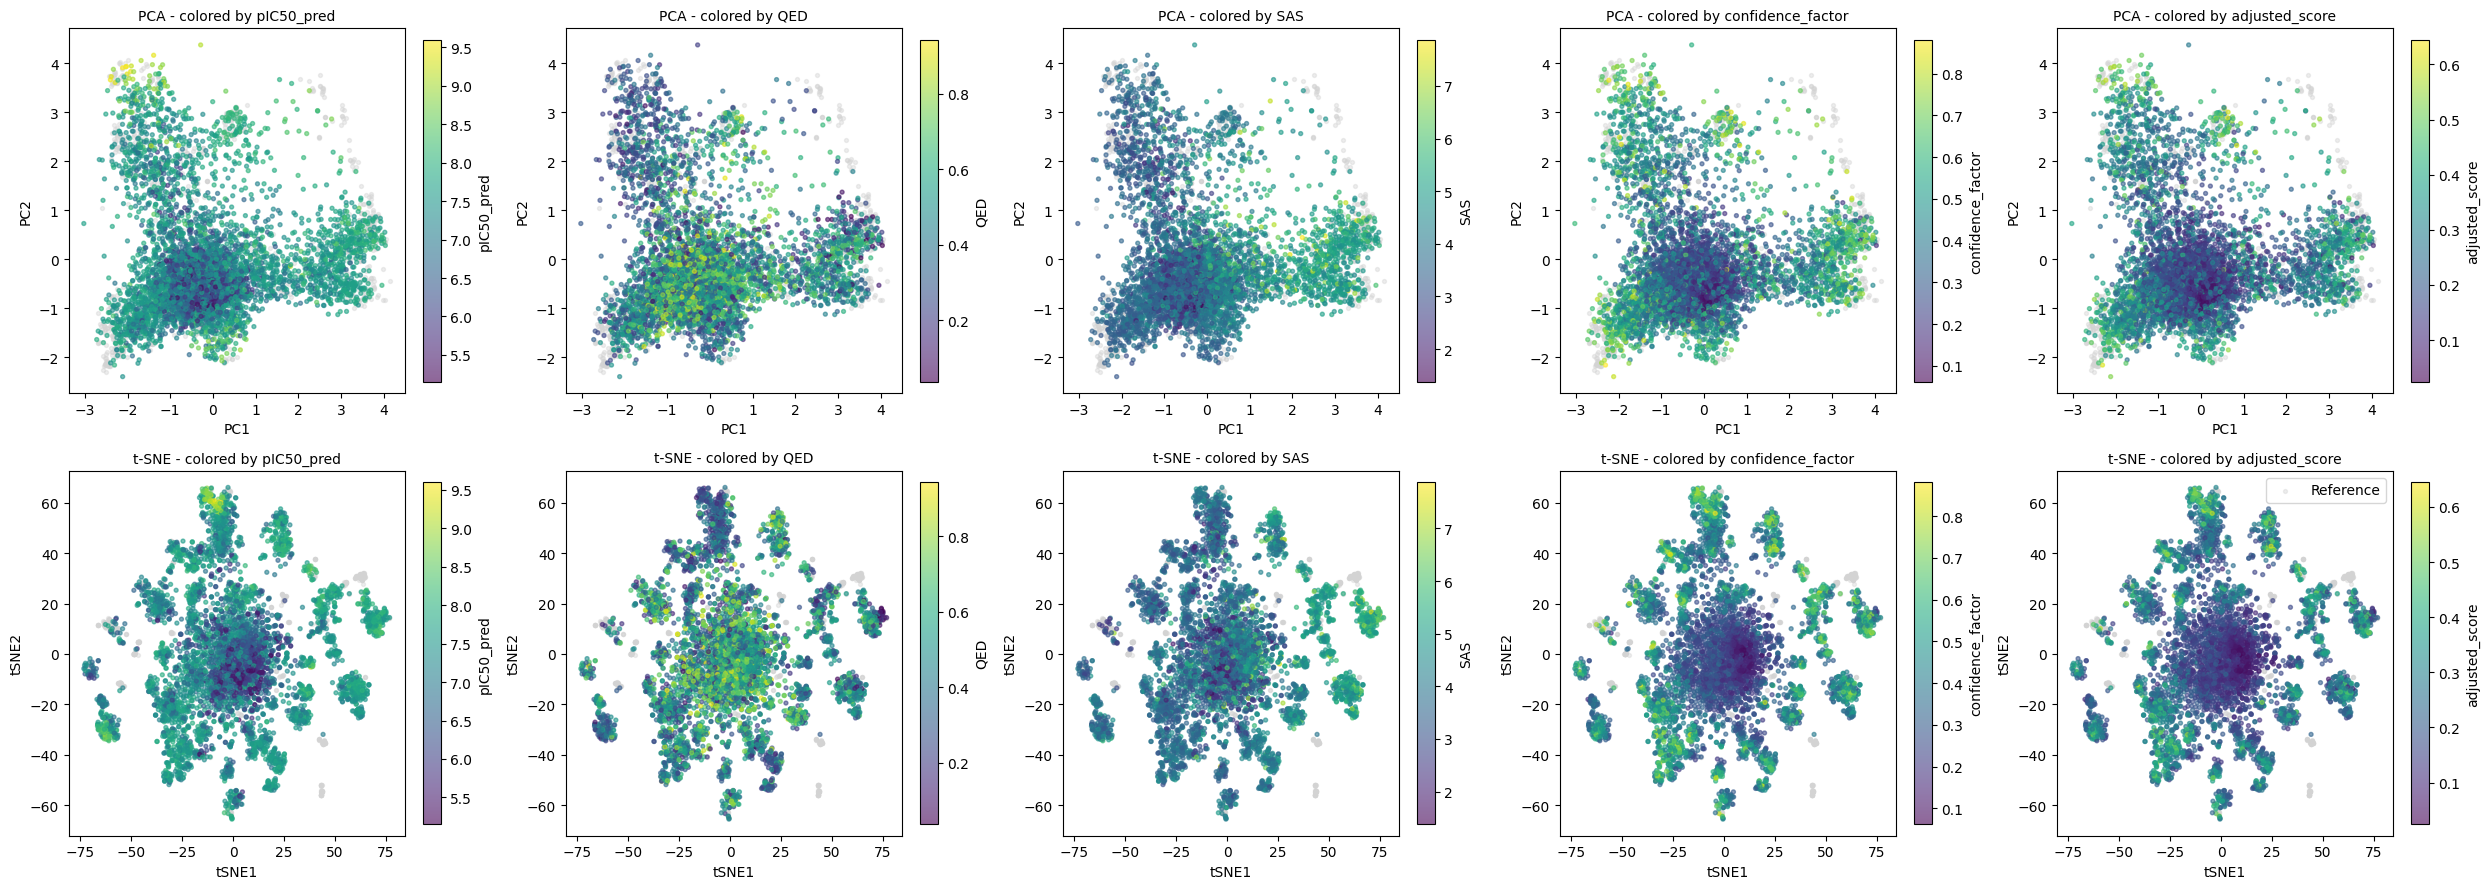

In [62]:
# PLOT: PCA and t-SNE colored by score
available_scores = [c for c in score_cols if c in plot_df.columns and plot_df[c].notna().any()]

fig, axes = plt.subplots(2, len(available_scores), figsize=(5 * len(available_scores), 9))
if len(available_scores) == 1:
    axes = axes.reshape(2, 1)

for i, score_col in enumerate(available_scores):
    # Riga 1: PCA
    ax = axes[0, i]
    # Reference in grigio chiaro come sfondo, de novo colorato per score
    ref_mask = plot_df["origin"] == "reference"
    denovo_mask = plot_df["origin"] == "de novo"

    ax.scatter(plot_df.loc[ref_mask, "PC1"], plot_df.loc[ref_mask, "PC2"],
               color="lightgray", alpha=0.4, s=8, label="Reference")
    sc = ax.scatter(plot_df.loc[denovo_mask, "PC1"], plot_df.loc[denovo_mask, "PC2"],
                     c=plot_df.loc[denovo_mask, score_col], cmap="viridis", alpha=0.6, s=8)
    ax.set_title(f"PCA - colored by {score_col}", fontsize=10)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.colorbar(sc, ax=ax, label=score_col, fraction=0.046)

    # Riga 2: t-SNE
    ax = axes[1, i]
    ax.scatter(plot_df.loc[ref_mask, "tSNE1"], plot_df.loc[ref_mask, "tSNE2"],
               color="lightgray", alpha=0.4, s=8, label="Reference")
    sc = ax.scatter(plot_df.loc[denovo_mask, "tSNE1"], plot_df.loc[denovo_mask, "tSNE2"],
                     c=plot_df.loc[denovo_mask, score_col], cmap="viridis", alpha=0.6, s=8)
    ax.set_title(f"t-SNE - colored by {score_col}", fontsize=10)
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")
    plt.colorbar(sc, ax=ax, label=score_col, fraction=0.046)

plt.legend()
plt.tight_layout()
plt.savefig("pca_tsne_by_score.png", dpi=150, bbox_inches="tight")
plt.show()

### PCA, t-SNE - Descriptors

In [65]:
# Combine descriptors for reference and de novo datasets
X_denovo_desc = df_denovo[descriptor_cols].values.astype(np.float32)
X_reference_desc = df_reference[descriptor_cols].values.astype(np.float32)

print(f"De novo molecules: {len(df_denovo)}")
print(f"Reference molecules: {len(df_reference)}")

De novo molecules: 99876
Reference molecules: 1460


In [67]:
# Subsample
MAX_DENOVO_POINTS = 5000

denovo_sample_idx = np.random.RandomState(42).choice(
    len(df_denovo), size=min(MAX_DENOVO_POINTS, len(df_denovo)), replace=False
)

df_denovo_sample = df_denovo.iloc[denovo_sample_idx].reset_index(drop=True)
df_reference_sample = df_reference.reset_index(drop=True)  # keep all reference

X_denovo_desc_sample = X_denovo_desc[denovo_sample_idx]
X_reference_desc_sample = X_reference_desc  # keep all reference

X_combined_desc = np.vstack([X_denovo_desc_sample, X_reference_desc_sample])
origin_sample = (["de novo"] * len(df_denovo_sample)) + (["reference"] * len(df_reference_sample))

print(f"\nSample for PCA/tSNE: {len(df_denovo_sample)} de novo (subsample) + "
      f"{len(df_reference_sample)} reference (complete) = {X_combined_desc.shape[0]} total")


Sample for PCA/tSNE: 5000 de novo (subsample) + 1460 reference (complete) = 6460 total


In [68]:
# Scaling
scaler = StandardScaler()
X_combined_scaled = scaler.fit_transform(X_combined_desc)

In [69]:
# PCA
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_combined_scaled)

print(f"\nPCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}")

# Bonus: quali descrittori contribuiscono di piu' a PC1/PC2 (loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=descriptor_cols
)
print("\nDescriptor contributions to the PCs:")
print(loadings.sort_values("PC1_loading", key=abs, ascending=False))


PCA explained variance: PC1=41.1%, PC2=26.9%

Descriptor contributions to the PCs:
               PC1_loading  PC2_loading
MW                0.536389     0.015402
RotBonds          0.449872     0.025312
TPSA              0.441945     0.345042
HBD               0.355138     0.367301
AromaticRings     0.326325    -0.526869
LogP              0.285389    -0.413940
FractionCSP3     -0.022997     0.544262


In [71]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_coords = tsne.fit_transform(X_combined_scaled)

In [72]:
# Dataframe with coordinates and scores
plot_df = pd.DataFrame({
    "PC1": pca_coords[:, 0],
    "PC2": pca_coords[:, 1],
    "tSNE1": tsne_coords[:, 0],
    "tSNE2": tsne_coords[:, 1],
    "origin": origin_sample,
})

# Score (only de novo)
score_cols = ["pIC50_pred", "QED", "SAS", "confidence_factor", "adjusted_score"]
for col in score_cols:
    if col in df_denovo_sample.columns:
        values = pd.concat([
            df_denovo_sample[col],
            pd.Series([np.nan] * len(df_reference_sample))
        ], ignore_index=True)
        plot_df[col] = values.values

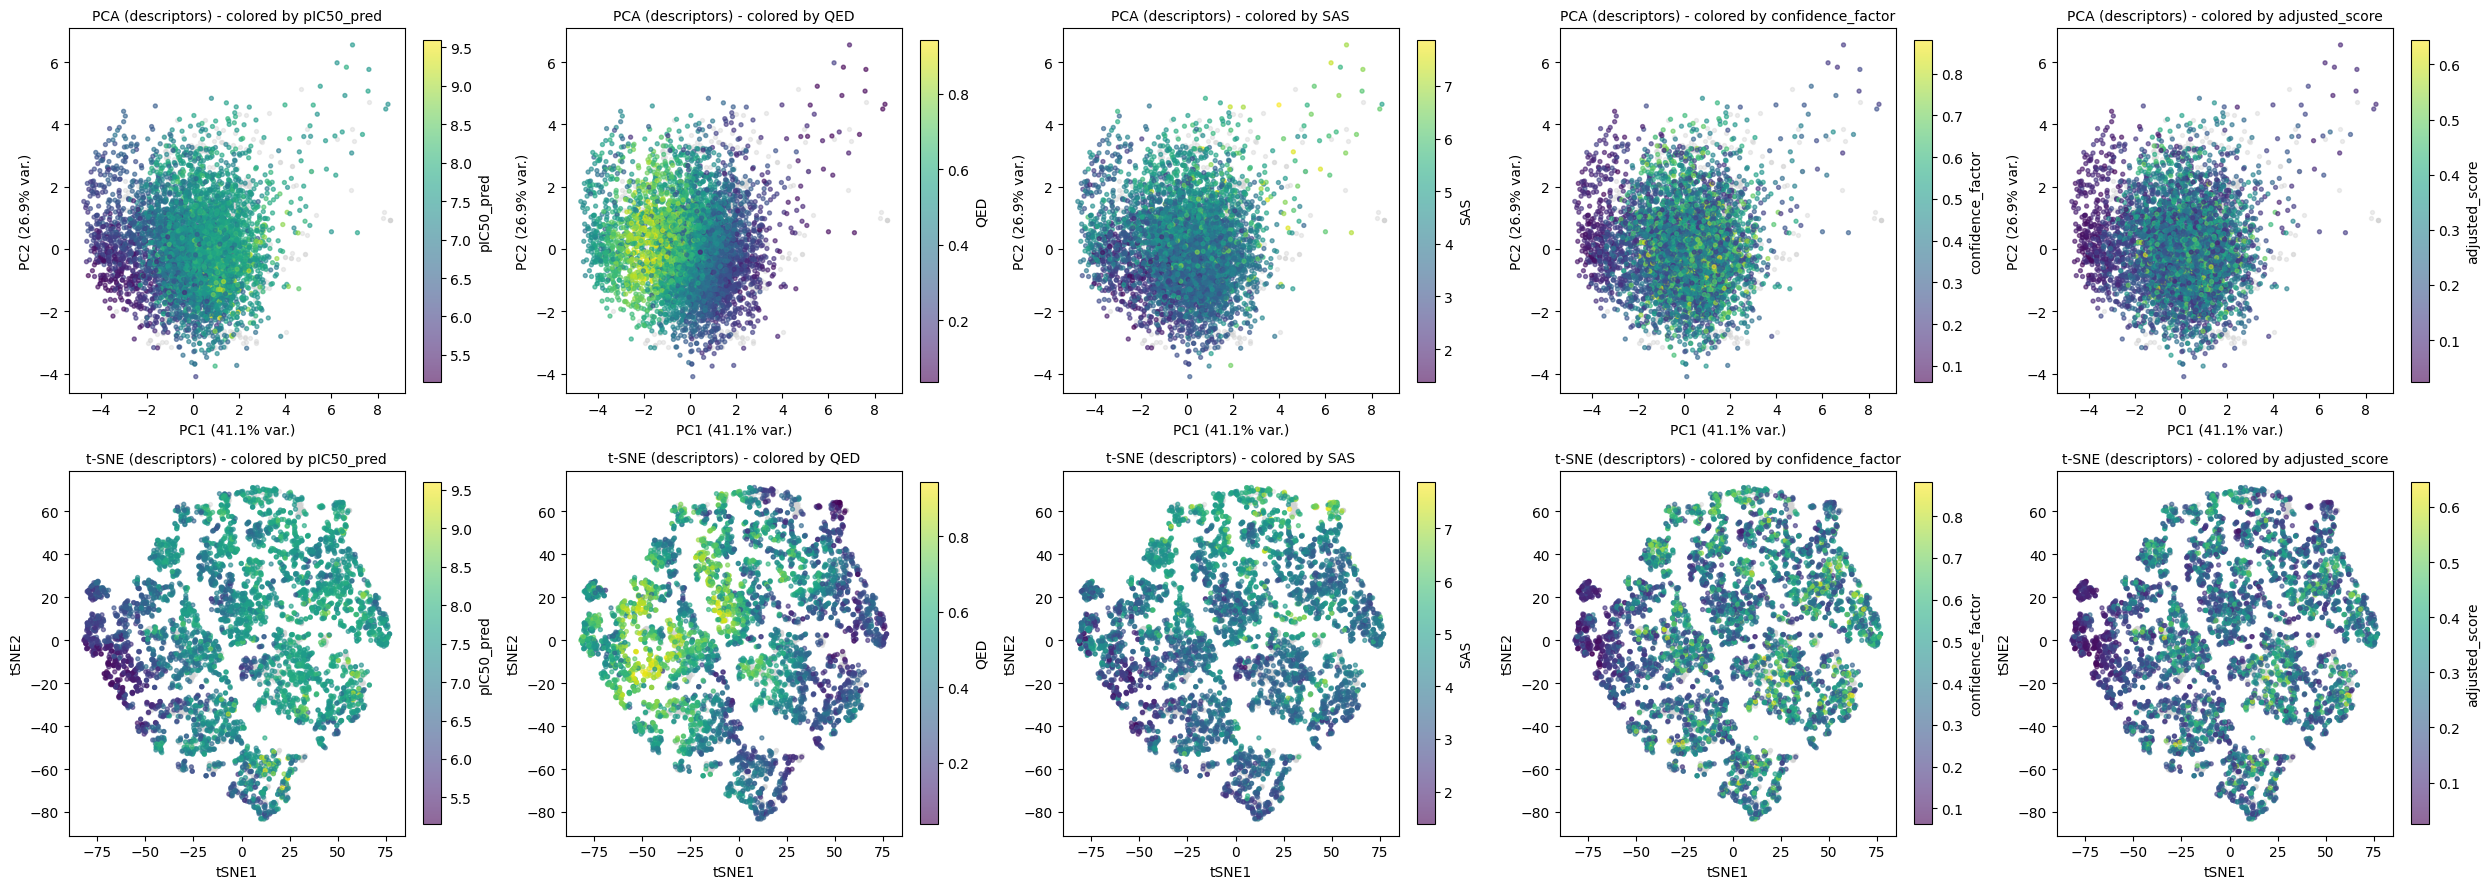

In [74]:
# PLOT: PCA and t-SNE colored by score
available_scores = [c for c in score_cols if c in plot_df.columns and plot_df[c].notna().any()]

fig, axes = plt.subplots(2, len(available_scores), figsize=(5 * len(available_scores), 9))
if len(available_scores) == 1:
    axes = axes.reshape(2, 1)

for i, score_col in enumerate(available_scores):
    # Riga 1: PCA
    ax = axes[0, i]
    ref_mask = plot_df["origin"] == "reference"
    denovo_mask = plot_df["origin"] == "de novo"

    ax.scatter(plot_df.loc[ref_mask, "PC1"], plot_df.loc[ref_mask, "PC2"],
               color="lightgray", alpha=0.4, s=8, label="Reference")
    sc = ax.scatter(plot_df.loc[denovo_mask, "PC1"], plot_df.loc[denovo_mask, "PC2"],
                     c=plot_df.loc[denovo_mask, score_col], cmap="viridis", alpha=0.6, s=8)
    ax.set_title(f"PCA (descriptors) - colored by {score_col}", fontsize=10)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)")
    plt.colorbar(sc, ax=ax, label=score_col, fraction=0.046)

    # Riga 2: t-SNE
    ax = axes[1, i]
    ax.scatter(plot_df.loc[ref_mask, "tSNE1"], plot_df.loc[ref_mask, "tSNE2"],
               color="lightgray", alpha=0.4, s=8, label="Reference")
    sc = ax.scatter(plot_df.loc[denovo_mask, "tSNE1"], plot_df.loc[denovo_mask, "tSNE2"],
                     c=plot_df.loc[denovo_mask, score_col], cmap="viridis", alpha=0.6, s=8)
    ax.set_title(f"t-SNE (descriptors) - colored by {score_col}", fontsize=10)
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")
    plt.colorbar(sc, ax=ax, label=score_col, fraction=0.046)

plt.tight_layout()
plt.savefig("pca_tsne_descriptors_by_score.png", dpi=150, bbox_inches="tight")
plt.show()